In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

In [ ]:
# Load Data
df = pd.read_csv("../data/profiler_10k_noisy.csv") # Check your path

# Input (X) and Output (y)
X = df[['Params', 'FLOPs', 'Layers', 'Hidden_Dim']].values
y = df['RAM_MB'].values.reshape(-1, 1)

# Split 60/20/20
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Scale Data (Crucial for Neural Networks)
scaler_x = StandardScaler()
scaler_y = MinMaxScaler() # Normalize target RAM to 0-1 for stability

X_train = scaler_x.fit_transform(X_train_raw)
X_val = scaler_x.transform(X_val_raw)
X_test = scaler_x.transform(X_test_raw)

y_train = scaler_y.fit_transform(y_train_raw)
y_val = scaler_y.transform(y_val_raw)
y_test = scaler_y.transform(y_test_raw)

# Convert to PyTorch Tensors
train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("✅ Data Processed & Loaders Ready")

In [ ]:
class ProfilerNN(nn.Module):
    def __init__(self):
        super(ProfilerNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Dropout(0.2), # Adds robustness (prevents 100% overfitting)
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Output: RAM
        )
        
    def forward(self, x):
        return self.net(x)

model = ProfilerNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print("✅ Model Architecture Created")

In [4]:
num_epochs = 50
train_losses = []
val_losses = []

print("🚀 Starting Training...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    # Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()
            
    # Record avg losses
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

print("✅ Training Complete")

🚀 Starting Training...
Epoch 5/50 | Train Loss: 0.00079 | Val Loss: 0.00049
Epoch 10/50 | Train Loss: 0.00065 | Val Loss: 0.00115
Epoch 15/50 | Train Loss: 0.00064 | Val Loss: 0.00117
Epoch 20/50 | Train Loss: 0.00056 | Val Loss: 0.00122
Epoch 25/50 | Train Loss: 0.00056 | Val Loss: 0.00120
Epoch 30/50 | Train Loss: 0.00058 | Val Loss: 0.00094
Epoch 35/50 | Train Loss: 0.00056 | Val Loss: 0.00126
Epoch 40/50 | Train Loss: 0.00052 | Val Loss: 0.00167
Epoch 45/50 | Train Loss: 0.00052 | Val Loss: 0.00111
Epoch 50/50 | Train Loss: 0.00053 | Val Loss: 0.00108
✅ Training Complete


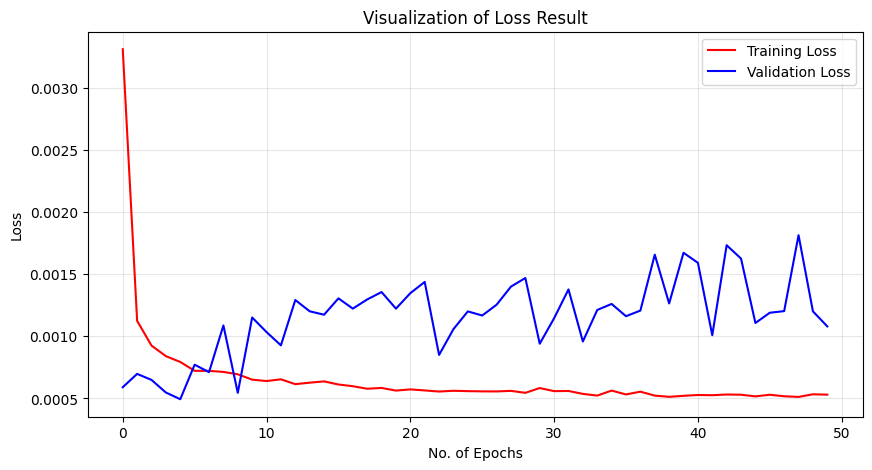

Final R2 Score: 0.9685


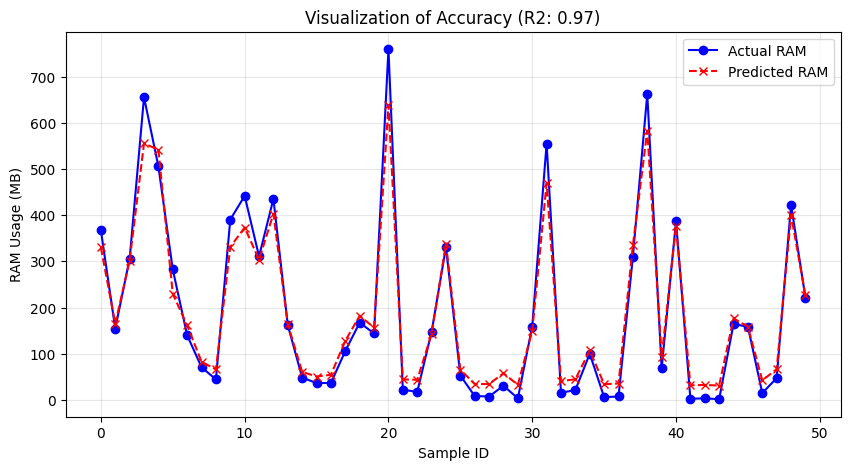

In [5]:
# --- BLOCK 1: LOSS GRAPH ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='red')
plt.plot(val_losses, label='Validation Loss', color='blue')
plt.xlabel('No. of Epochs')
plt.ylabel('Loss')
plt.title('Visualization of Loss Result')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- BLOCK 2: ACCURACY / PERFORMANCE GRAPH ---
model.eval()
with torch.no_grad():
    test_inputs = torch.FloatTensor(X_test).to(device)
    preds = model(test_inputs).cpu().numpy()

# Inverse transform to get real MB values
preds_mb = scaler_y.inverse_transform(preds)
actual_mb = scaler_y.inverse_transform(y_test)

# Calculate Realistic R2 Score
r2 = r2_score(actual_mb, preds_mb)
print(f"Final R2 Score: {r2:.4f}") 

# Graph: Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(actual_mb[:50], label='Actual RAM', color='blue', marker='o')
plt.plot(preds_mb[:50], label='Predicted RAM', color='red', linestyle='--', marker='x')
plt.title(f'Visualization of Accuracy (R2: {r2:.2f})')
plt.ylabel('RAM Usage (MB)')
plt.xlabel('Sample ID')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Save PyTorch Model
torch.save(model.state_dict(), 'profiler_nn_model.pth')

# Save Scalers (You MUST save these to use the model later)
joblib.dump(scaler_x, 'profiler_scaler_x.pkl')
joblib.dump(scaler_y, 'profiler_scaler_y.pkl')

print("✅ Files Saved. Download .pth and .pkl files from Output tab.")

✅ Files Saved. Download .pth and .pkl files from Output tab.


In [7]:
# --- FINAL TESTING BLOCK ---
print("🧪 RUNNING FINAL INDEPENDENT TEST...")

# 1. Create 5 Brand New, Never-Before-Seen Models (Simulated)
# [Params, FLOPs, Layers, Hidden_Dim]
test_cases = np.array([
    [1_200_000,   800_000_000,   18,  64],   # Small (e.g., MobileNet)
    [25_000_000,  4_000_000_000, 50,  256],  # Medium (e.g., ResNet50)
    [110_000_000, 15_000_000_000, 12, 768],  # Large (e.g., BERT Base)
    [500_000,     200_000_000,   5,   32],   # Tiny
    [60_000_000,  8_000_000_000, 100, 128]   # Deep but thin
])

# 2. Scale the Inputs (Using the saved scaler)
test_cases_scaled = scaler_x.transform(test_cases)
inputs_tensor = torch.FloatTensor(test_cases_scaled).to(device)

# 3. Predict
model.eval()
with torch.no_grad():
    predictions = model(inputs_tensor).cpu().numpy()

# 4. Inverse Transform to get MB
predicted_ram = scaler_y.inverse_transform(predictions)

# 5. Display Results
print(f"{'TEST CASE':<15} | {'PARAMS':<12} | {'LAYERS':<8} | {'PREDICTED RAM (MB)':<20}")
print("-" * 65)
names = ["MobileNet-ish", "ResNet50-ish", "BERT-ish", "TinyNet", "DeepNet"]

for i, name in enumerate(names):
    params = test_cases[i][0]
    layers = int(test_cases[i][2])
    ram = predicted_ram[i][0]
    print(f"{name:<15} | {params/1e6:.1f}M{'':<5} | {layers:<8} | {ram:.2f} MB")

print("-" * 65)
print("✅ If 'BERT-ish' RAM is significantly higher than 'TinyNet', the logic is valid.")

🧪 RUNNING FINAL INDEPENDENT TEST...
TEST CASE       | PARAMS       | LAYERS   | PREDICTED RAM (MB)  
-----------------------------------------------------------------
MobileNet-ish   | 1.2M      | 18       | 1587.96 MB
ResNet50-ish    | 25.0M      | 50       | 8565.32 MB
BERT-ish        | 110.0M      | 12       | 31606.17 MB
TinyNet         | 0.5M      | 5        | 288.56 MB
DeepNet         | 60.0M      | 100      | 17339.72 MB
-----------------------------------------------------------------
✅ If 'BERT-ish' RAM is significantly higher than 'TinyNet', the logic is valid.
